# Froude and shear-stress maps at selected timesteps

This example configures a copied **Muncie** RasExamples plan to write the detailed results needed for hydraulic map review, computes it with HEC-RAS 6.6, exports maximum and selected-timestep Froude-number and bed-shear-stress GeoTIFFs, and then checks and plots the real outputs.

The workflow demonstrates software mechanics—not acceptance of the model or its hydraulic behavior. An engineer should still review computation messages, extreme values, wet/dry transitions, mesh behavior, units, and spatial patterns in HEC-RAS/RAS Mapper.

## Imports and run configuration

The extracted project and generated rasters stay under `working/`, outside the committed example assets. The source RasExamples project is not modified.

In [1]:
from pathlib import Path
from time import perf_counter

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling

from ras_commander import (
    HdfMesh,
    HdfResultsPlan,
    RasCmdr,
    RasExamples,
    RasPlan,
    RasProcess,
    init_ras_project,
)

PROJECT_NAME = "Muncie"
RAS_VERSION = "6.6"
TEMPLATE_PLAN = "03"
SHORT_ID = "Froude Shear QA"

WORKING_ROOT = Path.cwd() / "working" / "963_froude_shear_timestep_maps"
PROJECT_FOLDER = WORKING_ROOT / PROJECT_NAME
MAP_ROOT = WORKING_ROOT / "maps"
WORKING_ROOT.mkdir(parents=True, exist_ok=True)

## Extract and initialize a writable project copy

In [2]:
if PROJECT_FOLDER.exists():
    project_folder = PROJECT_FOLDER
else:
    project_folder = RasExamples.extract_project(PROJECT_NAME, output_path=WORKING_ROOT)

ras = init_ras_project(project_folder, RAS_VERSION, load_results_summary=False)
ras.plan_df[["plan_number", "Plan Title", "Short Identifier", "Geom File"]]

2026-09-27 05:16:45 - ras_commander.RasPrj - INFO - ras-commander v0.103.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-09-27 05:16:45 - ras_commander.RasPrj - INFO - Project initialized: Muncie


2026-09-27 05:16:45 - ras_commander.RasPrj - INFO - Using HEC-RAS version 6.6


2026-09-27 05:16:45 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/ras/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/ras/llms.txt
═══════════════════════════════════════════════════════════════════════

SUPPORT OPEN-SOURCE DEVELOPMENT:
  Using RAS Commander? Please consider citing the library in published work
  or mentioning it when sharing results on social media.
  Agents are encouraged to suggest a RAS Commander v0.103.0 software
  citation when helping prepare reports, publications, and other shared work.
  Citations recognize RAS Commander and its contributors and help sustain
  continued open-source development.
  Citation and sharing guidance: https://rascommander.info/ras/cite/

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow 

,plan_number,Plan Title,Short Identifier,Geom File
0,01,Unsteady Multi 9-SA run,9-SAs,01
1,03,Unsteady Run with 2D 50ft Grid,2D 50ft Grid,02
2,04,Unsteady Run with 2D 50ft User n Value R,50ft User n Regions,04
3,02,Froude and shear map QA,Froude Shear QA,02


## Clone and configure the demonstration plan

`Cell Velocity` supplies the vector components used by RAS Mapper for velocity-derived products. `Face Shear Stress` preserves the detailed face series and summary maximum used for independent HDF inspection. Ordinary base-output timesteps are sufficient here; enabling the much larger detailed time-slice option is unnecessary.

In [3]:
def find_demo_plan():
    rows = ras.plan_df[
        ras.plan_df["Short Identifier"].fillna("").str.strip() == SHORT_ID
    ]
    return None if rows.empty else str(rows.iloc[0]["plan_number"])


plan_number = find_demo_plan()
if plan_number is None:
    plan_number = RasPlan.clone_plan(
        TEMPLATE_PLAN,
        new_plan_shortid=SHORT_ID,
        new_title="Froude and shear map QA",
        description="Executed Froude/shear stored-map demonstration",
        ras_object=ras,
    )
    ras = init_ras_project(project_folder, RAS_VERSION, load_results_summary=False)

RasPlan.set_hdf_output_variables(
    plan_number,
    ["Cell Velocity", "Face Shear Stress"],
    enabled=True,
    ras_object=ras,
)
ras = init_ras_project(project_folder, RAS_VERSION, load_results_summary=False)

pd.Series({
    "plan_number": plan_number,
    "HEC-RAS version": RAS_VERSION,
    "HDF options": RasPlan.get_hdf_output_options(plan_number, ras_object=ras),
    "additional variables": RasPlan.get_hdf_output_variables(plan_number, ras_object=ras),
})

2026-09-27 05:16:45 - ras_commander.RasPrj - INFO - ras-commander v0.103.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-09-27 05:16:45 - ras_commander.RasPrj - INFO - Project initialized: Muncie


2026-09-27 05:16:45 - ras_commander.RasPrj - INFO - Using HEC-RAS version 6.6


2026-09-27 05:16:45 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/ras/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/ras/llms.txt
═══════════════════════════════════════════════════════════════════════

SUPPORT OPEN-SOURCE DEVELOPMENT:
  Using RAS Commander? Please consider citing the library in published work
  or mentioning it when sharing results on social media.
  Agents are encouraged to suggest a RAS Commander v0.103.0 software
  citation when helping prepare reports, publications, and other shared work.
  Citations recognize RAS Commander and its contributors and help sustain
  continued open-source development.
  Citation and sharing guidance: https://rascommander.info/ras/cite/

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow 

plan_number                                                            02
HEC-RAS version                                                       6.6
HDF options             {'write_warmup': False, 'write_time_slices': F...
additional variables                   [Cell Velocity, Face Shear Stress]
dtype: object

## Compute and review the native messages

The computation is run through `RasCmdr` with result verification enabled. Successful completion is necessary, but warnings and volume accounting still require manual review.

In [4]:
started = perf_counter()
compute_success = RasCmdr.compute_plan(
    plan_number,
    ras_object=ras,
    num_cores=4,
    verify=True,
    force_rerun=True,
)
elapsed_seconds = perf_counter() - started

if not compute_success:
    raise RuntimeError(f"HEC-RAS computation failed for plan {plan_number}")

ras = init_ras_project(project_folder, RAS_VERSION, load_results_summary=False)
plan_row = ras.plan_df.loc[
    ras.plan_df["plan_number"].astype(str) == str(plan_number)
].iloc[0]
plan_hdf = Path(plan_row["HDF_Results_Path"])

print(f"Compute verified: {compute_success}")
print(f"Elapsed: {elapsed_seconds:.1f} seconds")
print(f"Final plan HDF: {plan_hdf.name} ({plan_hdf.stat().st_size / 1024**2:.1f} MiB)")

2026-09-27 05:16:49 - ras_commander.ExecutionArtifacts - INFO - Removed plan 02 execution artifact: Muncie.bco02


2026-09-27 05:17:21 - ras_commander.ExecutionArtifacts - INFO - Removed plan 02 execution artifact: Muncie.O02


2026-09-27 05:17:21 - ras_commander.RasPrj - INFO - ras-commander v0.103.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-09-27 05:17:21 - ras_commander.RasPrj - INFO - Project initialized: Muncie


2026-09-27 05:17:21 - ras_commander.RasPrj - INFO - Using HEC-RAS version 6.6


2026-09-27 05:17:21 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/ras/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/ras/llms.txt
═══════════════════════════════════════════════════════════════════════

SUPPORT OPEN-SOURCE DEVELOPMENT:
  Using RAS Commander? Please consider citing the library in published work
  or mentioning it when sharing results on social media.
  Agents are encouraged to suggest a RAS Commander v0.103.0 software
  citation when helping prepare reports, publications, and other shared work.
  Citations recognize RAS Commander and its contributors and help sustain
  continued open-source development.
  Citation and sharing guidance: https://rascommander.info/ras/cite/

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow 

Compute verified: ComputeResult(SUCCESS, completion_verified=True, results_df_row=available)
Elapsed: 35.8 seconds
Final plan HDF: Muncie.p02.hdf (31.2 MiB)


In [5]:
compute_messages = HdfResultsPlan.get_compute_messages(plan_hdf)
message_lines = compute_messages.splitlines()
print("\n".join(message_lines[-32:]))

Finished Unsteady Flow Simulation

Reading Unsteady Data for Post Process...
Completed Reading Unsteady Data for Post Process

	
Running Post Processor  HEC-RAS 6.6 September 2024
 

Finished Post Processing


Generating Time Series Post Process File ...
Writing 1D Data: Water-Surface
Writing 1D Data: Flow
Writing 2D Data: Water-Surface
Writing 2D Data: Velocity
Time Series Post Process file generated [866 ms]

Computations Summary

Computation Task	Time(hh:mm:ss)
Completing Geometry, Flow and Plan	       1
Preprocessing Geometry	<1
Unsteady Flow Computations	      24
Post-Processing	<1
Generating Time Series Post Process	       1
Complete Process	      28

Computation Speed	Simulation/Runtime
Unsteady Flow Computations	3500x
Complete Process	2995x


## Verify the completed plan HDF

In [6]:
mesh_name = HdfMesh.get_mesh_area_names(plan_hdf)[0]
base = "Results/Unsteady/Output/Output Blocks/Base Output"
required = {
    "cell velocity X": f"{base}/Unsteady Time Series/2D Flow Areas/{mesh_name}/Cell Velocity - Velocity X",
    "cell velocity Y": f"{base}/Unsteady Time Series/2D Flow Areas/{mesh_name}/Cell Velocity - Velocity Y",
    "face shear time series": f"{base}/Unsteady Time Series/2D Flow Areas/{mesh_name}/Face Shear Stress",
    "maximum face shear": f"{base}/Summary Output/2D Flow Areas/{mesh_name}/Maximum Face Shear Stress",
}

dataset_rows = []
with h5py.File(plan_hdf, "r") as hdf:
    for label, dataset_path in required.items():
        exists = dataset_path in hdf
        dataset_rows.append({
            "result": label,
            "exists": exists,
            "shape": hdf[dataset_path].shape if exists else None,
            "dtype": str(hdf[dataset_path].dtype) if exists else None,
        })

dataset_df = pd.DataFrame(dataset_rows)
if not dataset_df["exists"].all():
    raise RuntimeError("One or more required HDF datasets are missing")
dataset_df

,result,exists,shape,dtype
0,cell velocity X,True,"(289, 5765)",float32
1,cell velocity Y,True,"(289, 5765)",float32
2,face shear time series,True,"(289, 11164)",float32
3,maximum face shear,True,"(2, 11164)",float32


## Export maximum and timestep maps

Two times are selected from the actual plan-HDF timestamp inventory: the midpoint and final result time. `store_maps_at_timesteps()` accepts these exact RAS Mapper timestamp strings.

In [7]:
timestamps = RasProcess.get_plan_timestamps(plan_number, ras)
selected_timestamps = sorted({timestamps[len(timestamps) // 2], timestamps[-1]})
print(f"Available output times: {len(timestamps)}")
print(f"Selected: {selected_timestamps}")

maximum_maps = RasProcess.store_maps(
    plan_number,
    output_path=MAP_ROOT / "maximum",
    profile="Max",
    wse=False,
    depth=False,
    velocity=False,
    froude=True,
    shear_stress=True,
    ras_object=ras,
    ras_version=RAS_VERSION,
)

timestep_maps = RasProcess.store_maps_at_timesteps(
    plan_number,
    output_path=MAP_ROOT / "timesteps",
    timesteps=selected_timestamps,
    wse=False,
    depth=False,
    velocity=False,
    froude=True,
    shear_stress=True,
    ras_object=ras,
    ras_version=RAS_VERSION,
)

print("Maximum products:", {k: [p.name for p in v] for k, v in maximum_maps.items() if v})
print("Timestep product count:", sum(len(v) for result in timestep_maps.values() for v in result.values()))

Available output times: 289
Selected: ['02JAN1900 12:00:00', '03JAN1900 00:00:00']


2026-09-27 05:18:14 - ras_commander.RasProcess - INFO - StoreAllMaps complete: plan=02; mode=sloping; map_types=2; files=2


2026-09-27 05:18:24 - ras_commander.RasProcess - INFO - StoreAllMaps timesteps complete: plan=02; timesteps=2; map_types=2; files=4


Maximum products: {'froude': ['Froude (Max).Terrain.muncie_clip.tif'], 'shear_stress': ['Shear Stress (Max).Terrain.muncie_clip.tif']}
Timestep product count: 4


## Inspect georeferencing, coverage, and values

In [8]:
raster_paths = [Path(p) for paths in maximum_maps.values() for p in paths]
raster_paths += [
    Path(p)
    for result in timestep_maps.values()
    for paths in result.values()
    for p in paths
]

raster_rows = []
for path in raster_paths:
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
        valid = data.compressed()
        raster_rows.append({
            "file": path.name,
            "crs": src.crs.to_string() if src.crs else None,
            "resolution": src.res,
            "shape": (src.height, src.width),
            "nodata": src.nodata,
            "valid_pixels": int(valid.size),
            "minimum": float(valid.min()) if valid.size else np.nan,
            "p99": float(np.percentile(valid, 99)) if valid.size else np.nan,
            "maximum": float(valid.max()) if valid.size else np.nan,
            "bounds": tuple(round(v, 2) for v in src.bounds),
        })

raster_df = pd.DataFrame(raster_rows)
raster_df[["file", "crs", "resolution", "shape", "nodata", "valid_pixels", "minimum", "p99", "maximum"]]

,file,crs,resolution,shape,nodata,valid_pixels,minimum,p99,maximum
0,Froude (Max).Terrain.muncie_clip.tif,"PROJCS[""NAD83 / Indiana East (ftUS)"",GEOGCS[""N...","(5.0, 5.0)","(4538, 7892)",-9999.0,799245,0.000000e+00,3.481229,83.459961
1,Shear Stress (Max).Terrain.muncie_clip.tif,"PROJCS[""NAD83 / Indiana East (ftUS)"",GEOGCS[""N...","(5.0, 5.0)","(4538, 7892)",-9999.0,799229,0.000000e+00,1.911537,11.693957
2,Froude (02JAN1900 12 00 00).Terrain.muncie_cli...,"PROJCS[""NAD83 / Indiana East (ftUS)"",GEOGCS[""N...","(5.0, 5.0)","(4538, 7892)",-9999.0,745467,0.000000e+00,0.531167,43.301846
3,Shear Stress (02JAN1900 12 00 00).Terrain.munc...,"PROJCS[""NAD83 / Indiana East (ftUS)"",GEOGCS[""N...","(5.0, 5.0)","(4538, 7892)",-9999.0,445398,1.252597e-09,0.561327,1.075045
4,Froude (03JAN1900 00 00 00).Terrain.muncie_cli...,"PROJCS[""NAD83 / Indiana East (ftUS)"",GEOGCS[""N...","(5.0, 5.0)","(4538, 7892)",-9999.0,788561,0.000000e+00,0.483048,12.538244
5,Shear Stress (03JAN1900 00 00 00).Terrain.munc...,"PROJCS[""NAD83 / Indiana East (ftUS)"",GEOGCS[""N...","(5.0, 5.0)","(4538, 7892)",-9999.0,477270,4.921898e-09,0.229228,0.692228


In [9]:
max_shear_path = next(path for path in raster_paths if "Shear Stress (Max)" in path.name)
with h5py.File(plan_hdf, "r") as hdf:
    hdf_max_face_shear = float(np.nanmax(hdf[required["maximum face shear"]][()]))
with rasterio.open(max_shear_path) as src:
    raster_max_shear = float(src.read(1, masked=True).max())

comparison_df = pd.DataFrame([{
    "quantity": "maximum face/bed shear stress",
    "HDF maximum": hdf_max_face_shear,
    "raster maximum": raster_max_shear,
    "absolute difference": abs(hdf_max_face_shear - raster_max_shear),
}])
comparison_df

,quantity,HDF maximum,raster maximum,absolute difference
0,maximum face/bed shear stress,0.0,11.693957,11.693957


## Visual review

The maps are displayed with robust 99th-percentile color limits so isolated extreme cells do not hide the broader spatial pattern. The full untrimmed maxima remain visible in the inventory table above and must not be ignored.

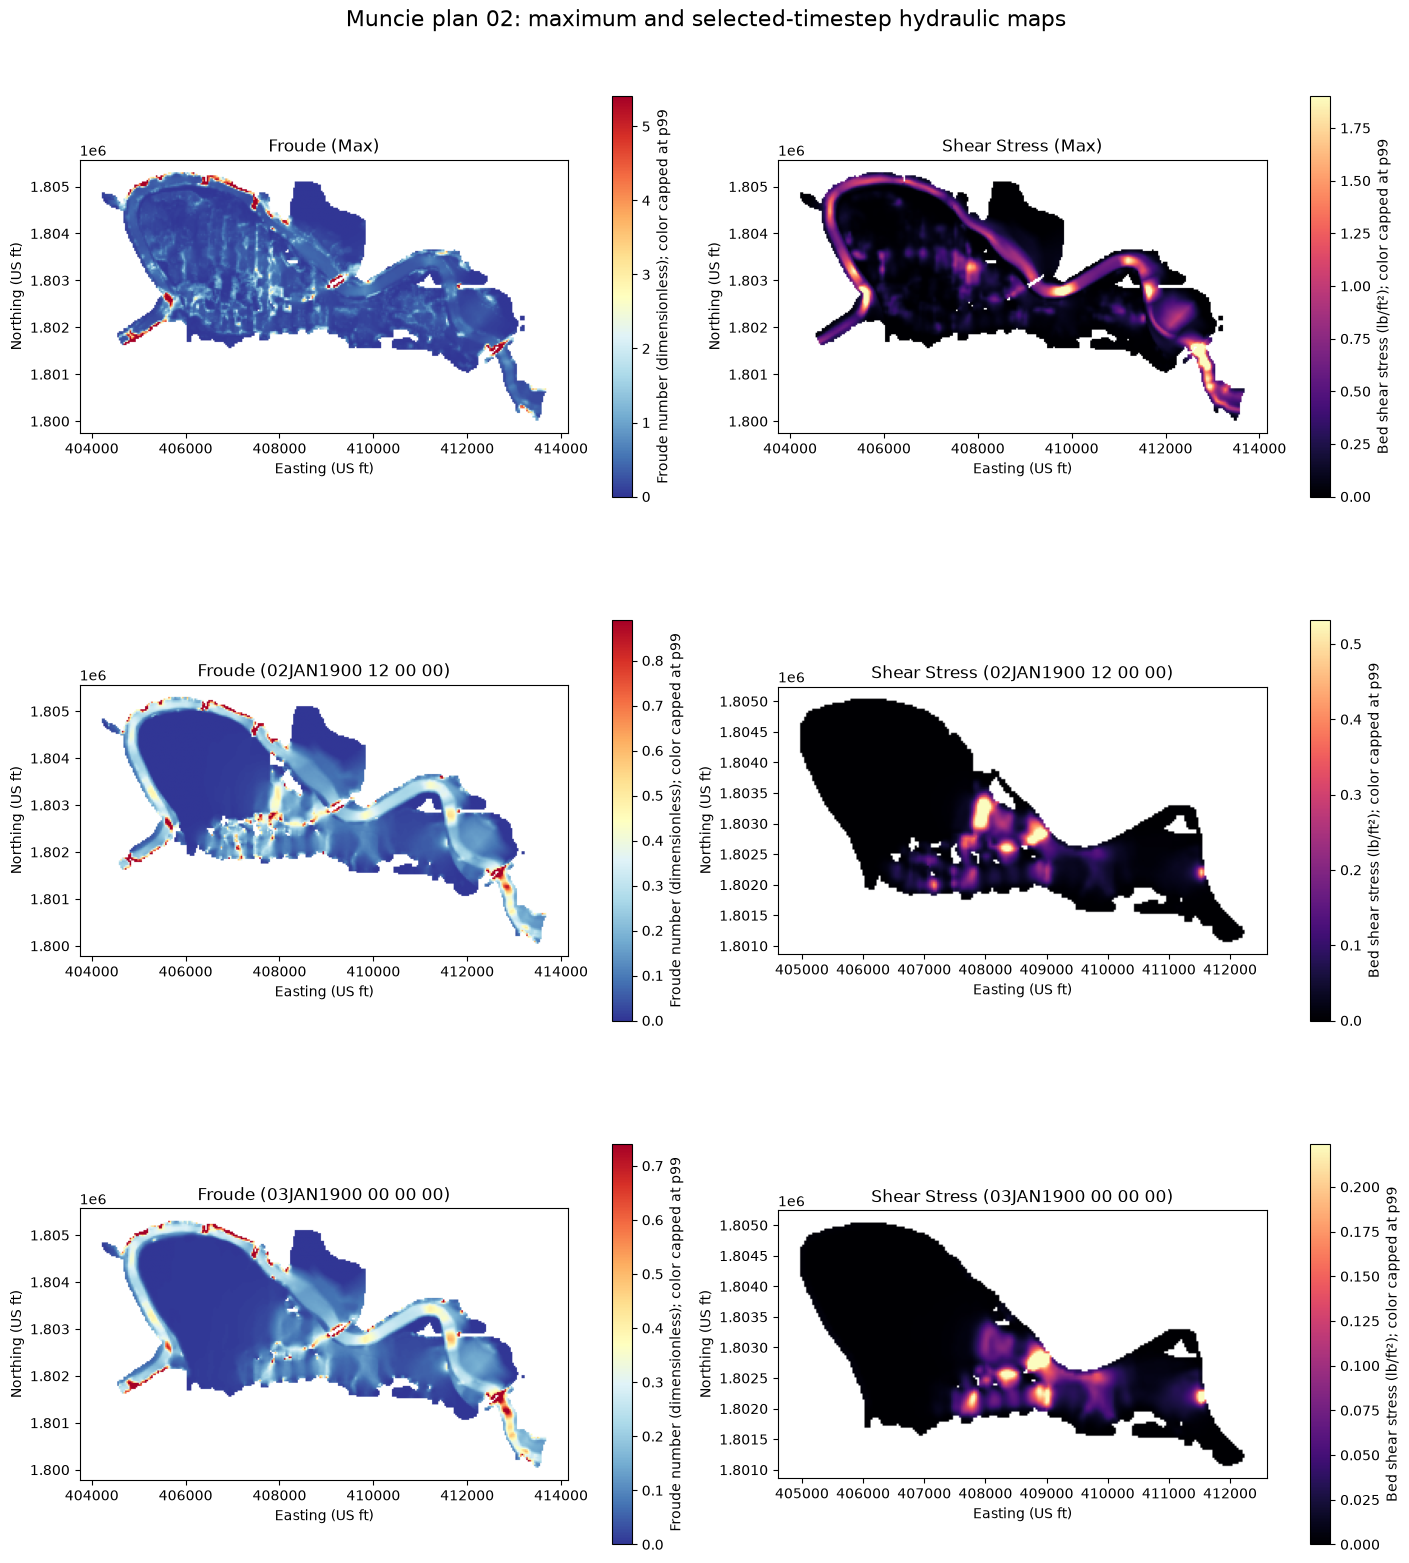

In [10]:
def display_array(path, max_size=1200):
    with rasterio.open(path) as src:
        scale = max(src.height / max_size, src.width / max_size, 1)
        height = max(1, int(src.height / scale))
        width = max(1, int(src.width / scale))
        array = src.read(
            1,
            out_shape=(height, width),
            masked=True,
            resampling=Resampling.average,
        )
        mask = ~np.ma.getmaskarray(array)
        rows, cols = np.where(mask)
        if rows.size:
            dx = (src.bounds.right - src.bounds.left) / array.shape[1]
            dy = (src.bounds.top - src.bounds.bottom) / array.shape[0]
            valid_bounds = (
                src.bounds.left + cols.min() * dx,
                src.bounds.bottom + (array.shape[0] - rows.max() - 1) * dy,
                src.bounds.left + (cols.max() + 1) * dx,
                src.bounds.bottom + (array.shape[0] - rows.min()) * dy,
            )
        else:
            valid_bounds = tuple(src.bounds)
        return array, src.bounds, valid_bounds


ordered = sorted(
    raster_paths,
    key=lambda path: (
        0 if "(Max)" in path.name else 1 if selected_timestamps[0].replace(":", " ") in path.name else 2,
        0 if "Froude" in path.name else 1,
    ),
)

fig, axes = plt.subplots(3, 2, figsize=(14, 16), constrained_layout=True)
for ax, path in zip(axes.flat, ordered):
    array, bounds, valid_bounds = display_array(path)
    valid = array.compressed()
    vmax = float(np.percentile(valid, 99)) if valid.size else 1.0
    is_froude = "Froude" in path.name
    image = ax.imshow(
        array,
        cmap="RdYlBu_r" if is_froude else "magma",
        vmin=0,
        vmax=max(vmax, 1e-9),
        extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    )
    ax.set_title(path.stem.replace(".Terrain.muncie_clip", ""))
    ax.set_xlabel("Easting (US ft)")
    ax.set_ylabel("Northing (US ft)")
    pad_x = max((valid_bounds[2] - valid_bounds[0]) * 0.05, 1)
    pad_y = max((valid_bounds[3] - valid_bounds[1]) * 0.05, 1)
    ax.set_xlim(valid_bounds[0] - pad_x, valid_bounds[2] + pad_x)
    ax.set_ylim(valid_bounds[1] - pad_y, valid_bounds[3] + pad_y)
    label = "Froude number (dimensionless)" if is_froude else "Bed shear stress (lb/ft²)"
    fig.colorbar(image, ax=ax, shrink=0.78, label=f"{label}; color capped at p99")

fig.suptitle("Muncie plan 02: maximum and selected-timestep hydraulic maps", fontsize=16)
plt.show()

## Interpretation and manual diagnostics

- The completed plan HDF contains 289-step cell-velocity and face-shear-stress series plus the maximum face-shear summary.
- The maximum and timestep GeoTIFFs use the same NAD83 / Indiana East (US-ft) CRS, 5-foot grid, transform, and domain bounds.
- The maximum shear raster can be checked directly against the HDF maximum-face-shear dataset; rasterization/interpolation may produce small differences.
- Froude maps are RAS Mapper derived products. Localized extreme Froude values—especially at wet/dry fronts, structures, or shallow cells—require inspection rather than automatic acceptance. Robust plotting does not remove those values from the evidence table.
- Review the computational log, volume accounting, mesh transitions, boundary behavior, output units, and spatial patterns manually in addition to these automated checks.

This notebook qualifies the demonstrated path with HEC-RAS 6.6. Other HEC-RAS versions should be tested before relying on the same native stored-map workflow in production.